In [1]:
# Install (Colab only)
!pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
batch_size = 128
noise_dim = 100
lr = 0.0002
epochs = 10

Load MNIST Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


Generator

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

Discriminator

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

Initialize Everything

In [6]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

Training Loop (Generator + Discriminator)

In [7]:
for epoch in range(epochs):
    for real_images, _ in dataloader:

        real_images = real_images.view(-1, 784).to(device)
        batch_size = real_images.size(0)

        # ==========================
        # Train Discriminator
        # ==========================

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Real loss
        real_output = discriminator(real_images)
        loss_real = criterion(real_output, real_labels)

        # Fake loss
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise).detach()
        fake_output = discriminator(fake_images)
        loss_fake = criterion(fake_output, fake_labels)

        d_loss = loss_real + loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ==========================
        # Train Generator
        # ==========================

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)
        output = discriminator(fake_images)

        # Generator wants discriminator to think fakes are real
        g_loss = criterion(output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

Epoch [1/10]  D Loss: 0.0810  G Loss: 5.8405
Epoch [2/10]  D Loss: 0.3957  G Loss: 5.3136
Epoch [3/10]  D Loss: 0.5459  G Loss: 5.0582
Epoch [4/10]  D Loss: 0.3251  G Loss: 3.8231
Epoch [5/10]  D Loss: 0.1216  G Loss: 4.4044
Epoch [6/10]  D Loss: 0.1087  G Loss: 4.8092
Epoch [7/10]  D Loss: 0.0927  G Loss: 4.2701
Epoch [8/10]  D Loss: 0.1260  G Loss: 6.7117
Epoch [9/10]  D Loss: 0.0881  G Loss: 5.5994
Epoch [10/10]  D Loss: 0.2450  G Loss: 5.7809


Visualize Generated Images

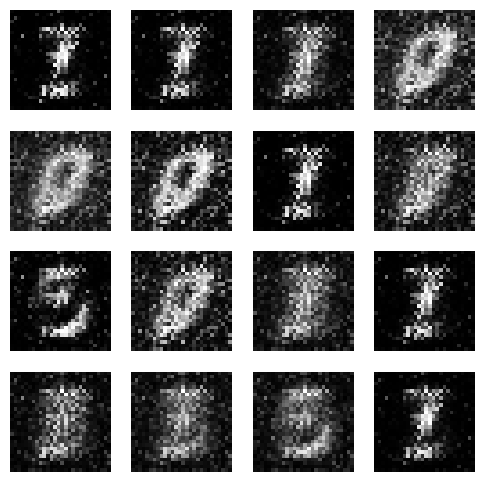

In [8]:
with torch.no_grad():
    noise = torch.randn(16, noise_dim).to(device)
    fake_images = generator(noise).view(-1, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(6,6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fake_images[i].cpu(), cmap='gray')
        ax.axis('off')
    plt.show()

What This Code Demonstrates

✔ Adversarial training
✔ Generator fooling discriminator
✔ Proper gradient flow
✔ Stable BCEWithLogitsLoss usage
✔ Correct detach during D training

Multi-Epoch GAN Training (Clean Implementation)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
batch_size = 128
noise_dim = 100
lr = 0.0002
epochs = 20

Dataset

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

Models

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

Initialize


In [12]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

Multi-Epoch Training Loop

In [13]:
for epoch in range(epochs):

    total_d_loss = 0
    total_g_loss = 0

    for real_images, _ in dataloader:

        real_images = real_images.view(-1, 784).to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ==========================
        # Train Discriminator
        # ==========================
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise).detach()

        real_output = discriminator(real_images)
        fake_output = discriminator(fake_images)

        loss_real = criterion(real_output, real_labels)
        loss_fake = criterion(fake_output, fake_labels)

        d_loss = loss_real + loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ==========================
        # Train Generator
        # ==========================
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)

        output = discriminator(fake_images)

        g_loss = criterion(output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    avg_d_loss = total_d_loss / len(dataloader)
    avg_g_loss = total_g_loss / len(dataloader)

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

Epoch [1/20] | D Loss: 0.2664 | G Loss: 4.1723
Epoch [2/20] | D Loss: 0.1791 | G Loss: 5.3661
Epoch [3/20] | D Loss: 0.5514 | G Loss: 4.1758
Epoch [4/20] | D Loss: 0.7647 | G Loss: 3.4063
Epoch [5/20] | D Loss: 0.7644 | G Loss: 3.0952
Epoch [6/20] | D Loss: 0.8929 | G Loss: 2.4970
Epoch [7/20] | D Loss: 0.5719 | G Loss: 2.8622
Epoch [8/20] | D Loss: 0.3337 | G Loss: 3.0910
Epoch [9/20] | D Loss: 0.4201 | G Loss: 3.6991
Epoch [10/20] | D Loss: 0.3314 | G Loss: 3.3841
Epoch [11/20] | D Loss: 0.3389 | G Loss: 3.9673
Epoch [12/20] | D Loss: 0.1958 | G Loss: 4.5499
Epoch [13/20] | D Loss: 0.1804 | G Loss: 5.2339
Epoch [14/20] | D Loss: 0.2150 | G Loss: 5.2452
Epoch [15/20] | D Loss: 0.2319 | G Loss: 5.1886
Epoch [16/20] | D Loss: 0.2323 | G Loss: 5.1713
Epoch [17/20] | D Loss: 0.2586 | G Loss: 5.0298
Epoch [18/20] | D Loss: 0.3044 | G Loss: 4.8676
Epoch [19/20] | D Loss: 0.4534 | G Loss: 4.4066
Epoch [20/20] | D Loss: 0.3406 | G Loss: 4.1494


What Happens Across Multiple Epochs?
Early epochs

D Loss ↓ quickly

G Loss ↑ initially

Outputs look like noise

Middle epochs

D Loss ≈ 1.2 – 1.4

G Loss stabilizes

Digits start forming

Later epochs

D Loss oscillates

G Loss oscillates

Images become sharper

That oscillation is normal in adversarial training.

using a trained GAN to generate synthetic data for augmenting other ML algorithms.

Goal

Use trained Generator to:

Generate synthetic samples

Combine them with real dataset

Train another ML model on augmented data

Step 1 — Generate Synthetic Data

In [14]:
generator.eval()

num_fake_samples = 5000

all_fake_images = []

with torch.no_grad():
    for _ in range(num_fake_samples // batch_size):
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)
        fake_images = fake_images.view(-1, 28, 28).cpu()
        all_fake_images.append(fake_images)

fake_dataset = torch.cat(all_fake_images)

Step 2 — Combine Real + Fake Data

In [15]:
fake_dataset = fake_dataset.view(-1, 784)

In [16]:
real_images = dataset.data.float() / 255.0
real_images = real_images.view(-1, 784)
real_labels = dataset.targets

In [17]:
fake_dataset = (fake_dataset + 1) / 2  # undo tanh normalization

In [18]:
augmented_images = torch.cat([real_images, fake_dataset], dim=0)

Step 3 — Train a Classifier on Augmented Data

Simple neural classifier:

In [21]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

Training loop:

In [25]:
classifier = Classifier().to(device)
optimizer = optim.Adam(classifier.parameters(), lr=0.001)
criterion_cls = nn.CrossEntropyLoss()

# Define fake_labels for the generated fake_dataset
# Assign random labels from 0-9 for the 10-class classifier
num_fake_samples_generated = fake_dataset.size(0) # This will be 4992
fake_labels_for_augmented_data = torch.randint(0, 10, (num_fake_samples_generated, 1), dtype=torch.long)

# Re-create augmented_labels with the newly defined fake_labels
augmented_labels = torch.cat([real_labels.view(-1, 1), fake_labels_for_augmented_data])

aug_dataset = torch.utils.data.TensorDataset(
    augmented_images,
    augmented_labels
)

aug_loader = torch.utils.data.DataLoader(
    aug_dataset,
    batch_size=128,
    shuffle=True
)

for epoch in range(5):
    for images, labels in aug_loader:
        images = images.to(device)
        labels = labels.to(device).squeeze() # Squeeze the labels to make them 1D

        outputs = classifier(images)
        loss = criterion_cls(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2779
Epoch 2, Loss: 0.3591
Epoch 3, Loss: 0.3639
Epoch 4, Loss: 0.1596
Epoch 5, Loss: 0.2426
